# **1. Imports, Initializations**

In [ ]:
%pip install Groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 7.4 MB/s eta 0:00:00


In [ ]:
%pip install nest_asyncio

In [ ]:
%pip install jedi>=0.16

In [ ]:
!pip install -q -U huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.6/663.6 kB 22.0 MB/s eta 0:00:00


In [ ]:
%pip install anthropic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.7/831.7 kB 41.7 MB/s eta 0:00:00


In [ ]:
!pip install networkx pydantic python-dotenv tenacity

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import re
import json
import random
import numpy as np
import torch
import nest_asyncio
nest_asyncio.apply()

# Reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [ ]:
from huggingface_hub import login
from google.colab import userdata
from groq import Groq
import anthropic

login(token=userdata.get('HF_TOKEN'))
client = Groq(api_key=userdata.get('your_groq_key'))
client_anth = anthropic.Anthropic(api_key=userdata.get('your_anthropic_key'))

In [ ]:
from tenacity import retry, stop_after_attempt, wait_exponential

# Quick sanity check
response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[{"role": "user", "content": "say: online"}],
    max_tokens=10,
)
print(response.choices[0].message.content)

Online


# **2. Schema Extraction**

In [ ]:
paper_text = """
TITLE: Planar Abelian mirror duals of N=2 SQCD3
AUTHORS: Sergio Benvenuti, Riccardo Comi, Sara Pasquetti, Gabriel Pedde Ungureanu, Simone Rota, Anant Shri

INTRODUCTION:
We propose an Abelian mirror dual for N=2 SU(N) Chern-Simons SQCD3. The dual theory is planar — a quiver drawn on a plane with cubic superpotential terms for each closed oriented loop, plus linear monopole superpotentials. Dualities are obtained by real mass deformations of 3d N=4 mirror pairs and display exchange of topological and flavor symmetries.

We focus on SU(N)_k SQCD3 with F >= 2N fundamentals and CS level k = F/2 - N.

MAIN DUALITY (Fig. 1 + Fig. 2):
Electric theory: SU(N)_{F/2 - N} with F fundamentals, supersymmetry N=2.
Obtained from N=4 SU(N) with F flavors by real mass deformation breaking SU(2)xSU(2) R-symmetry to U(1)_R. Adjoint and F antifundamentals become massive, integrated out, generating CS level F/2 - N.

Magnetic theory: Planar Abelian quiver (Fig. 2). All gauge groups are U(1).
- Black nodes carry CS level -1
- Red nodes carry CS level -1/2
- Each arrow = chiral field with charge (+1,-1) under connected nodes
- Mixed CS couplings: vertical arrows have -1, nonvertical arrows have +1
- Superpotential: W_planar (cubic terms, -1 for clockwise triangles, +1 for anticlockwise) + W_monopole (Polyakov mechanism, GNO flux +1 and -1 for nodes connected by vertical arrows)
- Global symmetry: U(1)^F in UV, enhances to U(F) in IR matching electric SU(F) flavor symmetry
- Evidence: S3_b partition function matched, superconformal index matched for N<5, F<11 up to O(x^{12/5})

EXPLICIT EXAMPLE 1: SU(2)_{1/2} with 5 fundamentals (Eq. 3 + Eq. 4)
Electric theory: SU(2)_{1/2} SQCD3 with F=5 fundamentals. Chiral ring generated by C(5,2)=10 baryons B_{j1,j2}.
Mirror theory: Planar Abelian quiver (Eq. 4). Fields: beta_i (R-charge 1), alpha_{i,j} and gamma_k (R-charge 1/2). FI parameters written in terms of real masses X_i reflecting embedding U(1)^5_top x U(1)_R -> U(5)_X x U(1)_R.

OPERATOR MAP (Eq. 6): 10 baryons B map to 10 monopole operators M on mirror side:
B <-> M_{-000/000}, M_{--00/000}, M_{---0/000}, M_{----/000},
      M_{--00/-00}, M_{---0/-00}, M_{----/-00},
      M_{---0/--0}, M_{----/--0}, M_{----/---}

SUPERCONFORMAL INDEX (Eq. 11):
I = 1 + 10f*x^{3/5} + 50f^2*x^{6/5} + 175f^3*x^{9/5} - 25*x^2 + O(x^{12/5})
Bold numbers = SU(5) representations, f = fugacity for baryonic U(1) in U(5).

RG FLOW + SECOND DUALITY (Eq. 12 + Eq. 13):
Starting from SU(2)_{1/2} with 5 fundamentals (Eq. 3), turn on positive real mass for X5.
Result: SU(2)_{1} with 4 fundamentals (Eq. 12). Change in F: -1, change in CS level: +1/2.
On mirror side: fields alpha_{1,3}, gamma_3, alpha_{2,3} become massive. Rightmost node decouples as U(1)_{-1} CS theory, effectively becomes flavor node.
Mirror of SU(2)_{1} with 4 fundamentals (Eq. 13): reduced planar quiver with two red nodes at CS level -1/2.

OPERATOR MAP for second duality (Eq. 14): 6 baryons B map to 6 monopoles:
B <-> M_{-00/00}, M_{--0/00}, M_{---/00}, M_{--0/-0}, M_{---/-0}, M_{---/--}

THIRD DUALITY — LINEAR QUIVER (Eq. 15):
Electric theory: T[SU(N)] chiral linear quiver. Global symmetry SU(N)_X x SU(N)_Y. Real mass deformation for commutant of U(1)_R and SU(N)_Y breaks SUSY to N=2, breaks SU(N)_Y -> U(1)^{N-1}_Y. Chiral adjoint multiplets and half the chiral bifundamentals integrated out.
For N=3: chiral linear quiver with U(1) and U(2) gauge nodes, CS level +1 for diagonal U(1) in each U(m), mixed CS level -1 between adjacent nodes.
Mirror theory (N=3): planar Abelian quiver (Eq. 15).
Operator map: N-1 dressed gauge invariant monopoles of electric theory <-> N-1 mesonic operators along shortest path between adjacent U(1) flavor nodes.

SYMMETRY EXCHANGE:
Mirror symmetry exchanges flavor symmetry SU(F) of electric SU(N) SQCD with topological U(1)^F of planar quiver, which enhances to U(F) in IR.
"""

In [ ]:
SCHEMA_PROMPT = """
You extract graph nodes and edges from physics papers about 3d mirror symmetry.

Return ONLY valid JSON, no explanation, no markdown fences.

NODE TYPES:
- Theory: {id, name, gauge_group, rank, cs_level, matter_content: {fundamentals, anti_fundamentals}, supersymmetry, s_confines, chapter_introduced, equation_ref, notes}
- Quiver: {id, name, gauge_nodes: [{node_id, gauge_group, cs_level, flavor_attached}], supersymmetry, quiver_type, equation_ref, notes}
- Operator: {id, name, type, spin, theory_id, dressing, equation_ref, notes}

EDGE TYPES:
- mirror_of: {id, source, target, duality_type, algorithm_derived, evidence}
- abelian_dual_of: {id, source, target, algorithm_steps, evidence}
- operator_map: {id, source_operator_id, target_operator_id, mirror_pair_id, map_type, evidence}
- rg_flows_to: {id, source, target, deformation_type, deformation_parameter, change_in_F, dual_deformation, evidence}
- symmetry_map: {id, mirror_pair_id, source_symmetry, target_symmetry, direction, ir_enhancement}

STRICT RULES:
1. rank means the rank of the gauge group as an integer. SU(N) has rank N-1. So SU(2) has rank 1, SU(3) has rank 2.
2. cs_level must be the specific numerical value for that theory, not a general formula. SU(2)_{1/2} has cs_level "1/2", not "F/2 - N".
3. duality_type must be exactly one of: "N=4-mirror", "N=2-planar-Abelian", "N=2-Aharony-like", "non-susy-planar-Abelian". For this paper use "N=2-planar-Abelian".
4. Extract EVERY individual operator separately. If there are 10 baryons and 10 monopoles, create 10 + 10 = 20 operator nodes, each with a unique id and name. Do NOT collapse them into one.
5. For each individual operator map (e.g. B_{12} <-> M_{-000/000}), create one operator_map edge. If there are 10 mappings, create 10 edges.
6. Normalise all USp/U Sp/Usp to USp.
7. IDs are snake_case e.g. "su2_half_5fund", "baryon_12", "monopole_m000_000".
8. map_type is one of: monopole-to-meson, meson-to-monopole, baryon-to-monopole, monopole-to-baryon, topological-to-flavor, other.
9. If a field is unknown, use null.
10. CS level constraint: for SU(N)_{k} with F fundamentals, k + F/2 must be integer. If extracted CS level violates this, flag it in notes rather than silently keeping it.

OUTPUT STRUCTURE:
{
  "theories": [...],
  "quivers": [...],
  "operators": [...],
  "mirror_edges": [...],
  "operator_maps": [...],
  "rg_flows": [...],
  "abelian_duals": [...],
  "symmetry_maps": [...]
}
"""

In [ ]:
@retry(stop=stop_after_attempt(3), wait=wait_exponential(multiplier=2, min=4, max=30))
def extract_graph(text: str) -> dict:
    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {"role": "system", "content": SCHEMA_PROMPT},
            {"role": "user", "content": f"Extract all nodes and edges from this physics paper:\n\n{text}"}
        ],
        max_tokens=8000,
        temperature=0.0,
    )

    raw = response.choices[0].message.content.strip()

    # Strip markdown fences if model adds them anyway
    if raw.startswith("```"):
        raw = raw.split("```")[1]
        if raw.startswith("json"):
            raw = raw[4:]
    raw = raw.strip()

    return json.loads(raw)

# Run it
extracted = extract_graph(paper_text)
print(json.dumps(extracted, indent=2))

{
  "theories": [
    {
      "id": "su2_half_5fund",
      "name": "SU(2)_{1/2} SQCD3 with 5 fundamentals",
      "gauge_group": "SU(2)",
      "rank": 1,
      "cs_level": "1/2",
      "matter_content": {
        "fundamentals": 5,
        "anti_fundamentals": 0
      },
      "supersymmetry": "N=2",
      "s_confines": null,
      "chapter_introduced": null,
      "equation_ref": "Eq. 3",
      "notes": null
    },
    {
      "id": "su2_1_4fund",
      "name": "SU(2)_{1} with 4 fundamentals",
      "gauge_group": "SU(2)",
      "rank": 1,
      "cs_level": "1",
      "matter_content": {
        "fundamentals": 4,
        "anti_fundamentals": 0
      },
      "supersymmetry": "N=2",
      "s_confines": null,
      "chapter_introduced": null,
      "equation_ref": "Eq. 12",
      "notes": null
    },
    {
      "id": "tsu3_chiral_linear_quiver",
      "name": "T[SU(3)] chiral linear quiver",
      "gauge_group": "SU(3)",
      "rank": 2,
      "cs_level": null,
      "matter_content

# **3. Validation**

The extracted JSON from Groq is just a Python dict. We have no guarantee it's actually correct — a field might be the wrong type, a required field might be missing, an enum value might be wrong. Pydantic lets us define what a valid `Theory` or `RGFlow` looks like, and will throw a clear error if something doesn't match.
Think of it as a schema enforcer. If Groq hallucinates a `cs_level` as an integer instead of a string, Pydantic catches it here before it corrupts the graph.


In [ ]:
from pydantic import BaseModel, field_validator
from typing import Optional, Union

class MatterContent(BaseModel):
    fundamentals: Optional[Union[int, str]] = None
    anti_fundamentals: Optional[Union[int, str]] = None

class Theory(BaseModel):
    id: str
    name: str
    gauge_group: str
    rank: Optional[int] = None
    cs_level: Optional[str] = None
    matter_content: MatterContent = MatterContent()
    supersymmetry: str
    s_confines: Optional[bool] = None
    chapter_introduced: Optional[int] = None
    equation_ref: Optional[str] = None
    notes: Optional[str] = None

class Quiver(BaseModel):
    id: str
    name: str
    gauge_nodes: list = []
    supersymmetry: str
    quiver_type: Optional[str] = None
    equation_ref: Optional[str] = None
    notes: Optional[str] = None

class Operator(BaseModel):
    id: str
    name: str
    type: str
    spin: Optional[str] = None
    theory_id: str
    dressing: Optional[str] = None
    equation_ref: Optional[str] = None
    notes: Optional[str] = None

class MirrorEdge(BaseModel):
    id: str
    source: str
    target: str
    duality_type: str
    algorithm_derived: Optional[bool] = None
    evidence: Optional[str] = None

class OperatorMap(BaseModel):
    id: str
    source_operator_id: str
    target_operator_id: str
    mirror_pair_id: str
    map_type: str
    evidence: Optional[str] = None

class RGFlow(BaseModel):
    id: str
    source: str
    target: str
    deformation_type: str
    deformation_parameter: Optional[str] = None
    change_in_F: Optional[Union[int, str]] = None
    dual_deformation: Optional[str] = None
    evidence: Optional[str] = None

class AbelianDual(BaseModel):
    id: str
    source: str
    target: str
    algorithm_steps: Optional[str] = None
    evidence: Optional[str] = None

class SymmetryMap(BaseModel):
    id: str
    mirror_pair_id: str
    source_symmetry: str
    target_symmetry: str
    direction: str
    ir_enhancement: Optional[str] = None

def validate_extraction(extracted: dict) -> dict:
    valid = {k: [] for k in extracted}
    invalid = {k: [] for k in extracted}

    model_map = {
        "theories": Theory,
        "quivers": Quiver,
        "operators": Operator,
        "mirror_edges": MirrorEdge,
        "operator_maps": OperatorMap,
        "rg_flows": RGFlow,
        "abelian_duals": AbelianDual,
        "symmetry_maps": SymmetryMap,
    }

    for key, Model in model_map.items():
        for item in extracted.get(key, []):
            try:
                valid[key].append(Model(**item))
            except Exception as e:
                invalid[key].append({"item": item, "error": str(e)})

    # Report
    for key in valid:
        n_valid = len(valid[key])
        n_invalid = len(invalid[key])
        print(f"{key}: {n_valid} valid, {n_invalid} invalid")
        for bad in invalid[key]:
            print(f"  ERROR in {key}: {bad['error']}")

    return valid, invalid

In [ ]:
valid, invalid = validate_extraction(extracted)

theories: 3 valid, 0 invalid
quivers: 3 valid, 0 invalid
operators: 32 valid, 0 invalid
mirror_edges: 3 valid, 0 invalid
operator_maps: 16 valid, 0 invalid
rg_flows: 1 valid, 0 invalid
abelian_duals: 0 valid, 0 invalid
symmetry_maps: 2 valid, 0 invalid


# **4. Graph Extraction, Visualization**

NetworkX is a Python graph library. A graph is just nodes + edges. We add each validated Theory/Quiver/Operator as a node (with all its fields as attributes), then add each edge type connecting the right node IDs.
The reason this matters: once it's a graph, we can ask questions like "give me all nodes reachable from `su2_half_5fund` by following `mirror_of` then `rg_flows_to`" — which is exactly what GraphRAG needs to do.

In [ ]:
import networkx as nx

def build_graph(valid: dict) -> nx.MultiDiGraph:
    G = nx.MultiDiGraph()  # directed, allows multiple edges between same nodes

    # Add nodes
    for theory in valid["theories"]:
        G.add_node(theory.id, node_type="Theory", **theory.model_dump())

    for quiver in valid["quivers"]:
        G.add_node(quiver.id, node_type="Quiver", **quiver.model_dump())

    for op in valid["operators"]:
        G.add_node(op.id, node_type="Operator", **op.model_dump())

    # Add edges
    for edge in valid["mirror_edges"]:
        G.add_edge(edge.source, edge.target,
                   edge_type="mirror_of", **edge.model_dump())
        # Mirror is symmetric so add reverse too
        G.add_edge(edge.target, edge.source,
                   edge_type="mirror_of", **edge.model_dump())

    for edge in valid["abelian_duals"]:
        G.add_edge(edge.source, edge.target,
                   edge_type="abelian_dual_of", **edge.model_dump())

    for edge in valid["operator_maps"]:
        G.add_edge(edge.source_operator_id, edge.target_operator_id,
                   edge_type="operator_map", **edge.model_dump())

    for edge in valid["rg_flows"]:
        G.add_edge(edge.source, edge.target,
                   edge_type="rg_flows_to", **edge.model_dump())

    for edge in valid["symmetry_maps"]:
        G.add_edge(edge.mirror_pair_id, edge.mirror_pair_id,
                   edge_type="symmetry_map", **edge.model_dump())

    # Summary
    print(f"Graph built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    node_types = {}
    edge_types = {}
    for _, d in G.nodes(data=True):
        t = d.get("node_type", "?")
        node_types[t] = node_types.get(t, 0) + 1
    for _, _, d in G.edges(data=True):
        t = d.get("edge_type", "?")
        edge_types[t] = edge_types.get(t, 0) + 1
    print("Node types:", node_types)
    print("Edge types:", edge_types)

    return G

Graph built: 37 nodes, 23 edges
Node types: {'Theory': 2, 'Quiver': 3, 'Operator': 32}
Edge types: {'mirror_of': 4, 'abelian_dual_of': 2, 'rg_flows_to': 1, 'operator_map': 16}


<Figure size 1400x900 with 0 Axes>

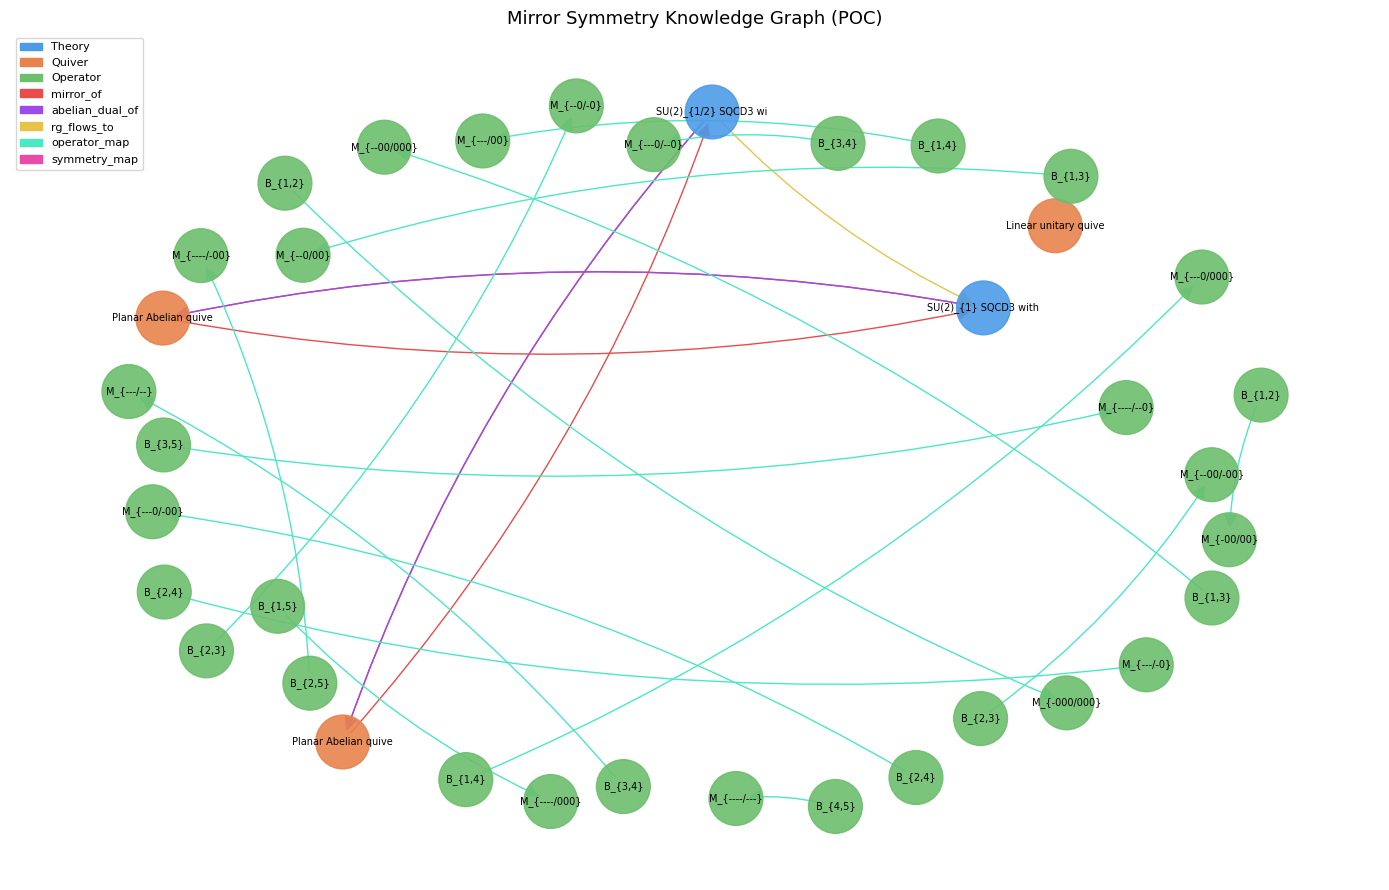

In [ ]:
import matplotlib.pyplot as plt

def visualise_graph(G: nx.MultiDiGraph, pos=None):
    plt.figure(figsize=(14, 9))

    if pos is None:
        pos = nx.spring_layout(G, seed=42, k=2)
    plt.figure(figsize=(14, 9))

    # Layout
    pos = nx.spring_layout(G, seed=42, k=2)

    # Color nodes by type
    color_map = {"Theory": "#4C9BE8", "Quiver": "#E8834C", "Operator": "#6DBE6D"}
    node_colors = [color_map.get(G.nodes[n].get("node_type", "?"), "grey") for n in G.nodes]

    # Color edges by type
    edge_color_map = {
        "mirror_of": "#E84C4C",
        "abelian_dual_of": "#9B4CE8",
        "rg_flows_to": "#E8C34C",
        "operator_map": "#4CE8C3",
        "symmetry_map": "#E84CA8",
    }
    edge_colors = [edge_color_map.get(d.get("edge_type", "?"), "grey")
                   for _, _, d in G.edges(data=True)]

    # Draw
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1500, alpha=0.9)
    nx.draw_networkx_labels(G, pos,
                            labels={n: G.nodes[n].get("name", n)[:20] for n in G.nodes},
                            font_size=7)
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors,
                           arrows=True, arrowsize=20,
                           connectionstyle="arc3,rad=0.1")

    # Legend
    from matplotlib.patches import Patch, FancyArrow
    node_legend = [Patch(color=c, label=t) for t, c in color_map.items()]
    edge_legend = [Patch(color=c, label=t) for t, c in edge_color_map.items()]
    plt.legend(handles=node_legend + edge_legend, loc="upper left", fontsize=8)

    plt.title("Mirror Symmetry Knowledge Graph (POC)", fontsize=13)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

G = build_graph(valid)

visualise_graph(G)

# **5. Multi-Hop Query**

In [ ]:
def multi_hop_query(G, start_name: str, edge_sequence: list[str]) -> list[dict]:
    """
    Traverse the graph following a sequence of edge types.

    Example: edge_sequence=["rg_flows_to", "mirror_of"] answers:
    "what is the mirror of the mass deformation of X?"
    """

    # Step 1: find the starting node by name fragment
    start_nodes = [
        n for n, d in G.nodes(data=True)
        if start_name.lower() in d.get("name", "").lower()
    ]

    if not start_nodes:
        print(f"No node found matching '{start_name}'")
        return []

    print(f"Starting from: {[G.nodes[n]['name'] for n in start_nodes]}")

    # Step 2: traverse edge by edge
    # frontier = list of (current_node_id, path_so_far)
    frontier = [(n, []) for n in start_nodes]

    for step, edge_type in enumerate(edge_sequence):
        next_frontier = []
        for node_id, path in frontier:
            # look at all outgoing edges from this node
            for _, target, data in G.out_edges(node_id, data=True):
                if data.get("edge_type") == edge_type:
                    next_frontier.append((
                        target,
                        path + [{
                            "from": G.nodes[node_id].get("name", node_id),
                            "edge": edge_type,
                            "to": G.nodes[target].get("name", target),
                            "evidence": data.get("evidence"),
                        }]
                    ))

        frontier = next_frontier
        if not frontier:
            print(f"Dead end at step {step+1} — no '{edge_type}' edges from current nodes")
            return []

    # Step 3: collect results
    results = []
    for node_id, path in frontier:
        node_data = dict(G.nodes[node_id])
        results.append({
            "answer_node": node_data.get("name", node_id),
            "node_type": node_data.get("node_type"),
            "path": path,
            "node_data": node_data,
        })

    return results

In [ ]:
# Query 1: "what is the mirror of SU(2) with 5 fundamentals?"
r1 = multi_hop_query(G, "SU(2)_{1/2}", ["mirror_of"])
for r in r1:
    print(f"Answer: {r['answer_node']}")
    for hop in r['path']:
        print(f"  {hop['from']} --[{hop['edge']}]--> {hop['to']} (evidence: {hop['evidence']})")

print("---")

# Query 2: "what is the mirror of the mass deformation of SU(2) with 5 fundamentals?"
r2 = multi_hop_query(G, "SU(2)_{1/2}", ["rg_flows_to", "mirror_of"])
for r in r2:
    print(f"Answer: {r['answer_node']}")
    for hop in r['path']:
        print(f"  {hop['from']} --[{hop['edge']}]--> {hop['to']} (evidence: {hop['evidence']})")

Starting from: ['SU(2)_{1/2} SQCD3 with 5 fundamentals', 'Planar Abelian quiver for SU(2)_{1/2} with 5 fundamentals']
Answer: Planar Abelian quiver for SU(2)_{1/2} with 5 fundamentals
  SU(2)_{1/2} SQCD3 with 5 fundamentals --[mirror_of]--> Planar Abelian quiver for SU(2)_{1/2} with 5 fundamentals (evidence: S3_b partition function matched, superconformal index matched for N<5, F<11 up to O(x^{12/5}))
Answer: SU(2)_{1/2} SQCD3 with 5 fundamentals
  Planar Abelian quiver for SU(2)_{1/2} with 5 fundamentals --[mirror_of]--> SU(2)_{1/2} SQCD3 with 5 fundamentals (evidence: S3_b partition function matched, superconformal index matched for N<5, F<11 up to O(x^{12/5}))
---
Starting from: ['SU(2)_{1/2} SQCD3 with 5 fundamentals', 'Planar Abelian quiver for SU(2)_{1/2} with 5 fundamentals']
Answer: Planar Abelian quiver for SU(2)_{1} with 4 fundamentals
  SU(2)_{1/2} SQCD3 with 5 fundamentals --[rg_flows_to]--> SU(2)_{1} with 4 fundamentals (evidence: Eq. 12)
  SU(2)_{1} with 4 fundamentals --

# **Reducing Noise**

In [ ]:
paper_text = """
TITLE: Planar Abelian mirror duals of N=2 SQCD3
AUTHORS: Sergio Benvenuti, Riccardo Comi, Sara Pasquetti, Gabriel Pedde Ungureanu, Simone Rota, Anant Shri

INTRODUCTION:
We propose an Abelian mirror dual for N=2 SU(N) Chern-Simons SQCD3. The dual theory is planar — a quiver drawn on a plane with cubic superpotential terms for each closed oriented loop, plus linear monopole superpotentials. Dualities are obtained by real mass deformations of 3d N=4 mirror pairs and display exchange of topological and flavor symmetries.

We focus on SU(N)_k SQCD3 with F >= 2N fundamentals and CS level k = F/2 - N.

MAIN DUALITY (Fig. 1 + Fig. 2):
Electric theory: SU(N)_{F/2 - N} with F fundamentals, supersymmetry N=2.
Obtained from N=4 SU(N) with F flavors by real mass deformation breaking SU(2)xSU(2) R-symmetry to U(1)_R. Adjoint and F antifundamentals become massive, integrated out, generating CS level F/2 - N.

Magnetic theory: Planar Abelian quiver (Fig. 2). All gauge groups are U(1).
- Black nodes carry CS level -1
- Red nodes carry CS level -1/2
- Each arrow = chiral field with charge (+1,-1) under connected nodes
- Mixed CS couplings: vertical arrows have -1, nonvertical arrows have +1
- Superpotential: W_planar (cubic terms, -1 for clockwise triangles, +1 for anticlockwise) + W_monopole (Polyakov mechanism, GNO flux +1 and -1 for nodes connected by vertical arrows)
- Global symmetry: U(1)^F in UV, enhances to U(F) in IR matching electric SU(F) flavor symmetry
- Evidence: S3_b partition function matched, superconformal index matched for N<5, F<11 up to O(x^{12/5})

EXPLICIT EXAMPLE 1: SU(2)_{1/2} with 5 fundamentals (Eq. 3 + Eq. 4)
Electric theory: SU(2)_{1/2} SQCD3 with F=5 fundamentals. Chiral ring generated by C(5,2)=10 baryons B_{j1,j2}.
Mirror theory: Planar Abelian quiver (Eq. 4). Fields: beta_i (R-charge 1), alpha_{i,j} and gamma_k (R-charge 1/2). FI parameters written in terms of real masses X_i reflecting embedding U(1)^5_top x U(1)_R -> U(5)_X x U(1)_R.

OPERATOR MAP (Eq. 6): 10 baryons map to 10 monopoles, one-to-one:
B_{1,2} <-> M_{-000/000}
B_{1,3} <-> M_{--00/000}
B_{1,4} <-> M_{---0/000}
B_{1,5} <-> M_{----/000}
B_{2,3} <-> M_{--00/-00}
B_{2,4} <-> M_{---0/-00}
B_{2,5} <-> M_{----/-00}
B_{3,4} <-> M_{---0/--0}
B_{3,5} <-> M_{----/--0}
B_{4,5} <-> M_{----/---}


SUPERCONFORMAL INDEX (Eq. 11):
I = 1 + 10f*x^{3/5} + 50f^2*x^{6/5} + 175f^3*x^{9/5} - 25*x^2 + O(x^{12/5})
Bold numbers = SU(5) representations, f = fugacity for baryonic U(1) in U(5).

RG FLOW + SECOND DUALITY (Eq. 12 + Eq. 13):
Starting from SU(2)_{1/2} with 5 fundamentals (Eq. 3), turn on positive real mass for X5.
Result: SU(2)_{1} with 4 fundamentals (Eq. 12). Change in F: -1, change in CS level: +1/2.
On mirror side: fields alpha_{1,3}, gamma_3, alpha_{2,3} become massive. Rightmost node decouples as U(1)_{-1} CS theory, effectively becomes flavor node.
Mirror of SU(2)_{1} with 4 fundamentals (Eq. 13): reduced planar quiver with two red nodes at CS level -1/2.

OPERATOR MAP for second duality (Eq. 14): 6 baryons map to 6 monopoles, one-to-one:
B_{1,2} <-> M_{-00/00}
B_{1,3} <-> M_{--0/00}
B_{1,4} <-> M_{---/00}
B_{2,3} <-> M_{--0/-0}
B_{2,4} <-> M_{---/-0}
B_{3,4} <-> M_{---/--}


THIRD DUALITY — LINEAR QUIVER (Eq. 15):
Electric theory: T[SU(N)] linear quiver. Global symmetry SU(N)_X x SU(N)_Y. Gauge symmetry U(1) x U(2) x ... U(N-1). N=4 T[SU(N)] is self-mirror under exchange of SU(N)_X and SU(N)_Y (background context only, do not extract as a separate node). Real mass deformation for commutant of U(1)_R and SU(N)_Y breaks SUSY to N=2, breaks SU(N)_Y -> U(1)^{N-1}_Y. Chiral adjoint multiplets and half the chiral bifundamentals integrated out.
For N=3: supersymmetry N=2 after real mass deformation. Gauge nodes are U(1) and U(2)
(not SU(3), the global symmetry is SU(3) but the gauge group is not).
CS level +1 for diagonal U(1) in each U(m), mixed CS level -1 between adjacent nodes.
quiver_type = "linear-unitary".
Mirror theory (N=3): planar Abelian quiver (Eq. 15).
Operator map: N-1 dressed gauge invariant monopoles of electric theory <-> N-1 mesonic operators along shortest path between adjacent U(1) flavor nodes.

SYMMETRY EXCHANGE:
Mirror symmetry exchanges flavor symmetry SU(F) of electric SU(N) SQCD with topological U(1)^F of planar quiver, which enhances to U(F) in IR. Equivalently, mesons/baryons are mapped to monopoles.
"""

In [ ]:
# refinining schema prompt so we fix the T[SU(N)] problem #
SCHEMA_PROMPT = """
You extract graph nodes and edges from physics papers about 3d mirror symmetry.

Return ONLY valid JSON, no explanation, no markdown fences.

NODE TYPES:
- Theory: {id, name, gauge_group, rank, cs_level, matter_content: {fundamentals, anti_fundamentals}, supersymmetry, s_confines, chapter_introduced, equation_ref, notes}
- Quiver: {id, name, gauge_nodes: [{node_id, gauge_group, cs_level, flavor_attached}], supersymmetry, quiver_type, equation_ref, notes}
- Operator: {id, name, type, spin, theory_id, dressing, equation_ref, notes}

EDGE TYPES:
- mirror_of: {id, source, target, duality_type, algorithm_derived, evidence}
- abelian_dual_of: {id, source, target, algorithm_steps, evidence}
- operator_map: {id, source_operator_id, target_operator_id, mirror_pair_id, map_type, evidence}
- rg_flows_to: {id, source, target, deformation_type, deformation_parameter, change_in_F, dual_deformation, evidence}
- symmetry_map: {id, mirror_pair_id, source_symmetry, target_symmetry, direction, ir_enhancement}

STRICT RULES:
1. rank is an integer = rank of the gauge group as a Lie algebra. SU(N) has rank N-1. So SU(2) has rank 1, SU(3) has rank 2. USp(2N) has rank N.
2. cs_level must be the specific numerical value for that theory instance, not a general formula. SU(2)_{1/2} has cs_level "1/2". SU(2)_{1} has cs_level "1". Never write "F/2 - N".
3. CS level constraint: for SU(N) with F fundamentals, k + F/2 must be an integer. If extracted CS level violates this, flag it in notes.
4. duality_type must be exactly one of: "N=4-mirror", "N=2-planar-Abelian", "N=2-Aharony-like", "non-susy-planar-Abelian". For this paper use "N=2-planar-Abelian".
5. A Theory is a SINGLE gauge group only. If a theory has multiple gauge nodes it is a Quiver, not a Theory.
6. T[SU(N)] is always a Quiver, never a Theory. For N=3: gauge_nodes = [U(1) with cs_level "1", U(2) with cs_level "1"], quiver_type = "linear-unitary", mixed CS level -1 between adjacent nodes goes in notes.
7. Planar Abelian mirror quivers go in "quivers", not "theories".
8. Extract EVERY individual operator separately with a unique id and name. 10 baryons = 10 separate operator nodes. Never collapse multiple operators into one. Never use placeholder indices like j1, j2, i, k — always use the specific numerical values from the paper. B_{1,2} and B_{1,3} are two separate nodes, NOT one node called B_{j1,j2}.
9. For each individual operator map create one operator_map edge. 10 mappings = 10 edges.
10. Create an abelian_dual_of edge when the mirror dual is a planar Abelian quiver, regardless of how it was derived (real mass deformation OR algorithmic procedure). Set algorithm_derived = true if the duality was obtained by an explicit algorithm (SL(2,Z) moves, planar Abelianisation procedure) rather than by partition function matching alone. Set algorithm_derived = false if only partition function/index evidence is given.
11. Normalise all USp/U Sp/Usp to USp.
12. IDs are snake_case e.g. "su2_half_5fund", "baryon_12", "monopole_m_minus000_000".
13. map_type is one of: monopole-to-meson, meson-to-monopole, baryon-to-monopole, monopole-to-baryon, topological-to-flavor, other.
14. If a field is unknown use null.

OUTPUT STRUCTURE:
{
  "theories": [...],
  "quivers": [...],
  "operators": [...],
  "mirror_edges": [...],
  "operator_maps": [...],
  "rg_flows": [...],
  "abelian_duals": [...],
  "symmetry_maps": [...]
}
"""

In [ ]:
@retry(stop=stop_after_attempt(3), wait=wait_exponential(multiplier=2, min=4, max=30))
def extract_graph(text: str) -> dict:
    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {"role": "system", "content": SCHEMA_PROMPT},
            {"role": "user", "content": f"Extract all nodes and edges from this physics paper:\n\n{text}"}
        ],
        max_tokens=8000,
        temperature=0.0,
    )

    raw = response.choices[0].message.content.strip()

    # Strip markdown fences if model adds them anyway
    if raw.startswith("```"):
        raw = raw.split("```")[1]
        if raw.startswith("json"):
            raw = raw[4:]
    raw = raw.strip()

    return json.loads(raw)

# Run it
extracted = extract_graph(paper_text)
print(json.dumps(extracted, indent=2))

{
  "theories": [
    {
      "id": "su2_half_5fund",
      "name": "SU(2)_{1/2} SQCD3 with 5 fundamentals",
      "gauge_group": "SU(2)",
      "rank": 1,
      "cs_level": "1/2",
      "matter_content": {
        "fundamentals": 5,
        "anti_fundamentals": 0
      },
      "supersymmetry": "N=2",
      "s_confines": null,
      "chapter_introduced": null,
      "equation_ref": "Eq. 3",
      "notes": null
    },
    {
      "id": "su2_1_4fund",
      "name": "SU(2)_{1} SQCD3 with 4 fundamentals",
      "gauge_group": "SU(2)",
      "rank": 1,
      "cs_level": "1",
      "matter_content": {
        "fundamentals": 4,
        "anti_fundamentals": 0
      },
      "supersymmetry": "N=2",
      "s_confines": null,
      "chapter_introduced": null,
      "equation_ref": "Eq. 12",
      "notes": null
    }
  ],
  "quivers": [
    {
      "id": "planar_abelian_quiver_su2_5fund",
      "name": "Planar Abelian quiver for SU(2)_{1/2} with 5 fundamentals",
      "gauge_nodes": [
        {


In [ ]:
valid, invalid = validate_extraction(extracted)

theories: 2 valid, 0 invalid
quivers: 3 valid, 0 invalid
operators: 32 valid, 0 invalid
mirror_edges: 2 valid, 0 invalid
operator_maps: 16 valid, 0 invalid
rg_flows: 1 valid, 0 invalid
abelian_duals: 2 valid, 0 invalid
symmetry_maps: 2 valid, 0 invalid


In [ ]:
def build_graph(valid: dict) -> nx.MultiDiGraph:
    G = nx.MultiDiGraph()

    # Build symmetry map lookup by mirror_pair_id
    sym_map_lookup = {}
    for s in valid["symmetry_maps"]:
        sym_map_lookup[s.mirror_pair_id] = {
            "source_symmetry": s.source_symmetry,
            "target_symmetry": s.target_symmetry,
            "direction": s.direction,
            "ir_enhancement": s.ir_enhancement,
        }

    # Add nodes
    for theory in valid["theories"]:
        G.add_node(theory.id, node_type="Theory", **theory.model_dump())

    for quiver in valid["quivers"]:
        G.add_node(quiver.id, node_type="Quiver", **quiver.model_dump())

    for op in valid["operators"]:
        G.add_node(op.id, node_type="Operator", **op.model_dump())

    # Add mirror_of edges — now carrying symmetry map as attributes
    for edge in valid["mirror_edges"]:
        sym_data = sym_map_lookup.get(edge.id, {})
        G.add_edge(edge.source, edge.target,
                   edge_type="mirror_of",
                   **edge.model_dump(),
                   **sym_data)
        G.add_edge(edge.target, edge.source,
                   edge_type="mirror_of",
                   **edge.model_dump(),
                   **sym_data)

    for edge in valid["abelian_duals"]:
        G.add_edge(edge.source, edge.target,
                   edge_type="abelian_dual_of", **edge.model_dump())

    for edge in valid["operator_maps"]:
        G.add_edge(edge.source_operator_id, edge.target_operator_id,
                   edge_type="operator_map", **edge.model_dump())

    for edge in valid["rg_flows"]:
        G.add_edge(edge.source, edge.target,
                   edge_type="rg_flows_to", **edge.model_dump())

     # Summary
    print(f"Graph built: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    node_types = {}
    edge_types = {}
    for _, d in G.nodes(data=True):
        t = d.get("node_type", "?")
        node_types[t] = node_types.get(t, 0) + 1
    for _, _, d in G.edges(data=True):
        t = d.get("edge_type", "?")
        edge_types[t] = edge_types.get(t, 0) + 1
    print("Node types:", node_types)
    print("Edge types:", edge_types)

    return G



Graph built: 39 nodes, 23 edges
Node types: {'Theory': 2, 'Quiver': 3, 'Operator': 32, '?': 2}
Edge types: {'mirror_of': 4, 'abelian_dual_of': 2, 'rg_flows_to': 1, 'operator_map': 16}


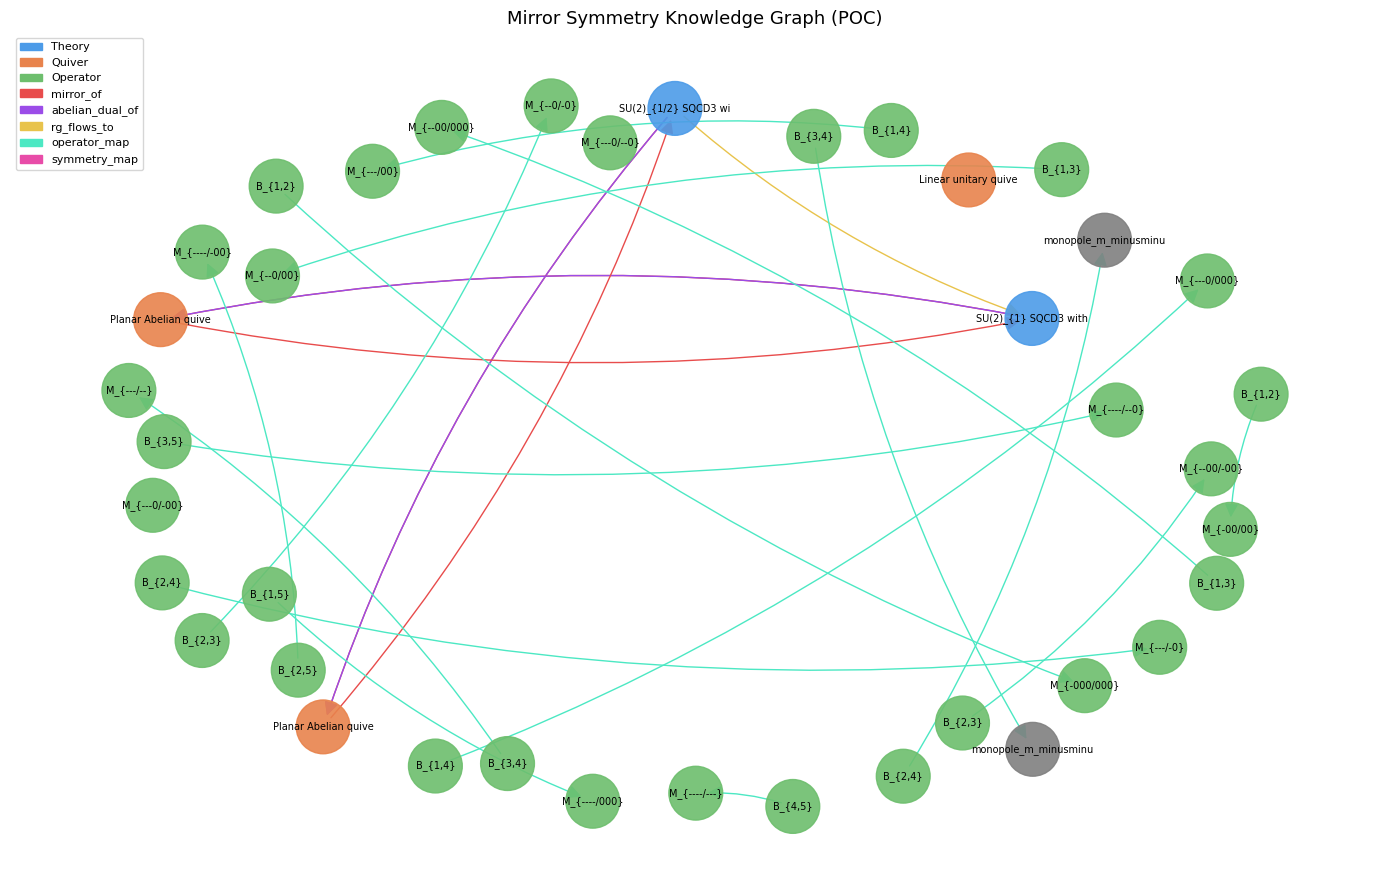

In [ ]:
G = build_graph(valid)

visualise_graph(G)

In [ ]:
from datetime import datetime

def save_extraction(extracted: dict, label: str = ""):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"extraction_{label}_{timestamp}.json" if label else f"extraction_{timestamp}.json"
    with open(filename, "w") as f:
        json.dump(extracted, f, indent=2)
    print(f"Saved to {filename}")
    return filename

# Run immediately after extract_graph()
filename = save_extraction(extracted, label="poc_v3")

Saved to extraction_poc_v3_20260519_075042.json


In [ ]:
def multi_hop_query(G, start_name: str, edge_sequence: list[str],
                    start_node_type: str = "Theory") -> list[dict]:

    # Only match nodes of the right type
    start_nodes = [
        n for n, d in G.nodes(data=True)
        if start_name.lower() in d.get("name", "").lower()
        and d.get("node_type") == start_node_type
    ]

    if not start_nodes:
        print(f"No {start_node_type} node found matching '{start_name}'")
        return []

    print(f"Starting from: {[G.nodes[n]['name'] for n in start_nodes]}")

    frontier = [(n, []) for n in start_nodes]

    for step, edge_type in enumerate(edge_sequence):
        next_frontier = []
        for node_id, path in frontier:
            for _, target, data in G.out_edges(node_id, data=True):
                if data.get("edge_type") == edge_type:
                    next_frontier.append((
                        target,
                        path + [{
                            "from": G.nodes[node_id].get("name", node_id),
                            "edge": edge_type,
                            "to": G.nodes[target].get("name", target),
                            "evidence": data.get("evidence"),
                        }]
                    ))

        frontier = next_frontier
        if not frontier:
            print(f"Dead end at step {step+1} — no '{edge_type}' edges from current nodes")
            return []

    results = []
    for node_id, path in frontier:
        node_data = dict(G.nodes[node_id])
        results.append({
            "answer_node": node_data.get("name", node_id),
            "node_type": node_data.get("node_type"),
            "path": path,
            "node_data": node_data,
        })

    return results

In [ ]:
# Query 1: "what is the mirror of SU(2) with 5 fundamentals?"
r1 = multi_hop_query(G, "SU(2)_{1/2}", ["mirror_of"])
for r in r1:
    print(f"Answer: {r['answer_node']}")
    for hop in r['path']:
        print(f"  {hop['from']} --[{hop['edge']}]--> {hop['to']} (evidence: {hop['evidence']})")

print("---")

# Query 2: "what is the mirror of the mass deformation of SU(2) with 5 fundamentals?"
r2 = multi_hop_query(G, "SU(2)_{1/2}", ["rg_flows_to", "mirror_of"])
for r in r2:
    print(f"Answer: {r['answer_node']}")
    for hop in r['path']:
        print(f"  {hop['from']} --[{hop['edge']}]--> {hop['to']} (evidence: {hop['evidence']})")

Starting from: ['SU(2)_{1/2} SQCD3 with 5 fundamentals']
Answer: Planar Abelian quiver for SU(2)_{1/2} with 5 fundamentals
  SU(2)_{1/2} SQCD3 with 5 fundamentals --[mirror_of]--> Planar Abelian quiver for SU(2)_{1/2} with 5 fundamentals (evidence: S3_b partition function matched, superconformal index matched)
---
Starting from: ['SU(2)_{1/2} SQCD3 with 5 fundamentals']
Answer: Planar Abelian quiver for SU(2)_{1} with 4 fundamentals
  SU(2)_{1/2} SQCD3 with 5 fundamentals --[rg_flows_to]--> SU(2)_{1} SQCD3 with 4 fundamentals (evidence: Eq. 12)
  SU(2)_{1} SQCD3 with 4 fundamentals --[mirror_of]--> Planar Abelian quiver for SU(2)_{1} with 4 fundamentals (evidence: S3_b partition function matched, superconformal index matched)


In [ ]:
def operator_map_query(G, operator_name: str) -> list[dict]:
    """
    Given an operator name fragment, find what it maps to across the duality.
    Traverses: Operator --[operator_map]--> Operator
    Also retrieves the parent theory of each operator.
    """

    # Find matching operator nodes
    start_nodes = [
        n for n, d in G.nodes(data=True)
        if operator_name.lower() in d.get("name", "").lower()
        and d.get("node_type") == "Operator"
    ]

    if not start_nodes:
        print(f"No operator found matching '{operator_name}'")
        return []

    print(f"Found operators: {[G.nodes[n]['name'] for n in start_nodes]}")

    results = []
    for op_id in start_nodes:
        op_data = dict(G.nodes[op_id])

        # Find parent theory
        parent_id = op_data.get("theory_id")
        parent_name = G.nodes[parent_id].get("name") if parent_id in G.nodes else parent_id

        # Follow operator_map edges
        for _, target, data in G.out_edges(op_id, data=True):
            if data.get("edge_type") == "operator_map":
                target_data = dict(G.nodes[target])
                target_parent_id = target_data.get("theory_id")
                target_parent_name = (G.nodes[target_parent_id].get("name")
                                      if target_parent_id in G.nodes
                                      else target_parent_id)
                results.append({
                    "source_operator": op_data.get("name"),
                    "source_theory": parent_name,
                    "target_operator": target_data.get("name"),
                    "target_theory": target_parent_name,
                    "map_type": data.get("map_type"),
                    "evidence": data.get("evidence"),
                })

    return results

In [ ]:
# Single operator lookup
r = operator_map_query(G, "B_{1,5}")
for result in r:
    print(f"{result['source_operator']} (in {result['source_theory']})")
    print(f"  --[{result['map_type']}]-->")
    print(f"  {result['target_operator']} (in {result['target_theory']})")
    print(f"  evidence: {result['evidence']}")

Found operators: ['B_{1,5}']
B_{1,5} (in SU(2)_{1/2} SQCD3 with 5 fundamentals)
  --[baryon-to-monopole]-->
  M_{----/000} (in Planar Abelian quiver for SU(2)_{1/2} with 5 fundamentals)
  evidence: Eq. 6


In [ ]:
for n, d in G.nodes(data=True):
    if d.get("node_type") is None or d.get("node_type") == "?":
        print(f"Phantom node: {n}")
        print(f"  attributes: {d}")
        print(f"  in_edges: {list(G.in_edges(n, data=True))}")
        print(f"  out_edges: {list(G.out_edges(n, data=True))}")

Phantom node: monopole_m_minusminusminus0_minus00
  attributes: {}
  in_edges: [('baryon_24', 'monopole_m_minusminusminus0_minus00', {'edge_type': 'operator_map', 'id': 'operator_map_baryon_24', 'source_operator_id': 'baryon_24', 'target_operator_id': 'monopole_m_minusminusminus0_minus00', 'mirror_pair_id': 'mirror_edge_su2_half_5fund', 'map_type': 'baryon-to-monopole', 'evidence': 'Eq. 6'})]
  out_edges: []
Phantom node: monopole_m_minusminusminus0_minus0
  attributes: {}
  in_edges: [('baryon_34', 'monopole_m_minusminusminus0_minus0', {'edge_type': 'operator_map', 'id': 'operator_map_baryon_34', 'source_operator_id': 'baryon_34', 'target_operator_id': 'monopole_m_minusminusminus0_minus0', 'mirror_pair_id': 'mirror_edge_su2_half_5fund', 'map_type': 'baryon-to-monopole', 'evidence': 'Eq. 6'})]
  out_edges: []


In [ ]:
for op in valid["operators"]:
    if "minus0" in op.id:
        print(op.id, "|", op.name)

monopole_m_minus000_000 | M_{-000/000}
monopole_m_minusminus00_000 | M_{--00/000}
monopole_m_minusminusminus0_000 | M_{---0/000}
monopole_m_minusminus00_minus00 | M_{--00/-00}
monopole_m_minusminusminus_minus00 | M_{---0/-00}
monopole_m_minusminusminusminus_minus00 | M_{----/-00}
monopole_m_minusminusminus_minus0 | M_{---0/--0}
monopole_m_minusminusminusminus_minus0 | M_{----/--0}
monopole_m_minus00_00 | M_{-00/00}
monopole_m_minusminus0_00 | M_{--0/00}
monopole_m_minusminus0_minus0 | M_{--0/-0}
monopole_m_minusminus_minus0 | M_{---/-0}


In [ ]:
for op in valid["operators"]:
    if op.id in ["baryon_24", "baryon_34"]:
        print(op.id, "|", op.name, "|", op.theory_id)

baryon_24 | B_{2,4} | su2_half_5fund
baryon_34 | B_{3,4} | su2_half_5fund


In [ ]:
# Fix dangling operator_map edge targets
id_fix = {
    "monopole_m_minusminusminus0_minus00": "monopole_m_minusminusminus_minus00",
    "monopole_m_minusminusminus0_minus0": "monopole_m_minusminusminus_minus0",
}

for om in valid["operator_maps"]:
    if om.target_operator_id in id_fix:
        print(f"Fixing: {om.target_operator_id} -> {id_fix[om.target_operator_id]}")
        om.target_operator_id = id_fix[om.target_operator_id]

# Rebuild
G = build_graph(valid)

Fixing: monopole_m_minusminusminus0_minus00 -> monopole_m_minusminusminus_minus00
Fixing: monopole_m_minusminusminus0_minus0 -> monopole_m_minusminusminus_minus0
Graph built: 37 nodes, 23 edges
Node types: {'Theory': 2, 'Quiver': 3, 'Operator': 32}
Edge types: {'mirror_of': 4, 'abelian_dual_of': 2, 'rg_flows_to': 1, 'operator_map': 16}


<Figure size 1400x900 with 0 Axes>

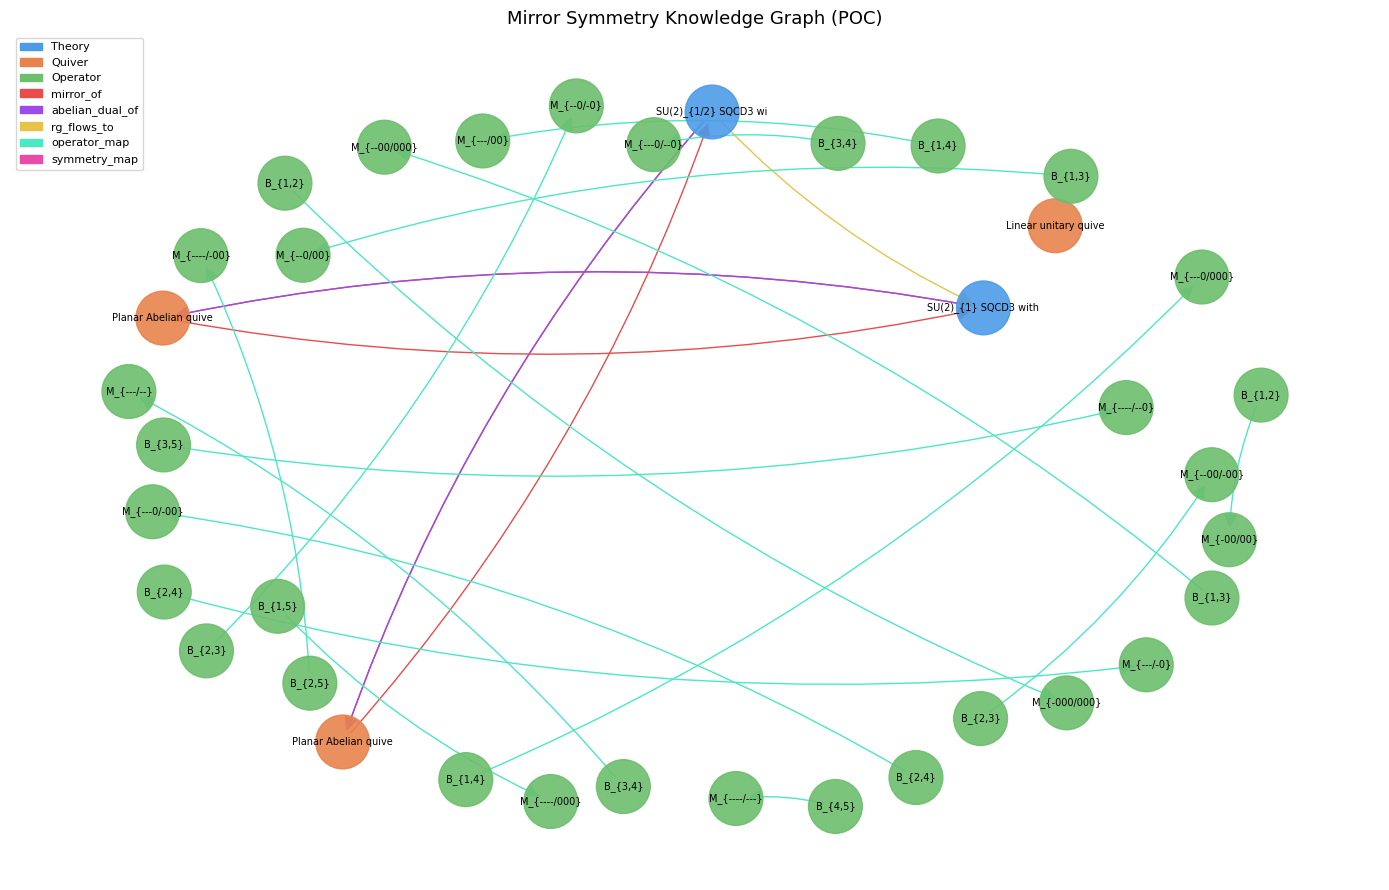

In [ ]:
pos = nx.multipartite_layout(G, subset_key="node_type")
visualise_graph(G, pos=pos)

# **Synthesis**

In [ ]:
def synthesise_answer(question: str, traversal_result: list[dict]) -> str:
    """
    Takes a question and graph traversal result, returns natural language answer.
    """
    if not traversal_result:
        return "No relevant information found in the graph for this question."

    # Format the traversal result into a readable context
    context_lines = []
    for result in traversal_result:
        context_lines.append(f"Answer node: {result['answer_node']} ({result['node_type']})")
        for hop in result['path']:
            context_lines.append(
                f"  {hop['from']} --[{hop['edge']}]--> {hop['to']} "
                f"(evidence: {hop['evidence']})"
            )
        # Add relevant node data
        nd = result['node_data']
        if nd.get('cs_level'):
            context_lines.append(f"  CS level: {nd['cs_level']}")
        if nd.get('supersymmetry'):
            context_lines.append(f"  Supersymmetry: {nd['supersymmetry']}")
        if nd.get('gauge_nodes'):
            context_lines.append(f"  Gauge nodes: {nd['gauge_nodes']}")

    context = "\n".join(context_lines)

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {
                "role": "system",
                "content": """You are an expert in 3d mirror symmetry answering questions
about gauge theories. You are given graph traversal results from a knowledge graph
built from a physics paper. Answer the question precisely and concisely using the
graph data provided. Always cite the evidence references. If the path involves
multiple hops explain each step."""
            },
            {
                "role": "user",
                "content": f"QUESTION: {question}\n\nGRAPH TRAVERSAL RESULT:\n{context}"
            }
        ],
        max_tokens=512,
        temperature=0.0,
    )

    return response.choices[0].message.content.strip()

In [ ]:
def ask(question: str, edge_sequence: list[str],
        start_node_type: str = "Theory") -> str:
    """
    Full pipeline: question -> graph traversal -> synthesis -> answer.
    """
    # Extract entity from question to use as search term
    # For now: just take the longest quoted or capitalised fragment
    # We'll improve this with intent classification later

    traversal = multi_hop_query(G, question, edge_sequence, start_node_type)
    answer = synthesise_answer(question, traversal)
    return answer

In [ ]:
# Entity to search for in graph
entity = "SU(2)_{1/2}"

print("Q: What is the mirror of SU(2)_{1/2} with 5 fundamentals?")
print(synthesise_answer(
    "What is the mirror of SU(2)_{1/2} with 5 fundamentals?",
    multi_hop_query(G, entity, ["mirror_of"])
))

print("\n---\n")

print("Q: What is the mirror of the mass deformation of SU(2)_{1/2} with 5 fundamentals?")
print(synthesise_answer(
    "What is the mirror of the mass deformation of SU(2)_{1/2} with 5 fundamentals?",
    multi_hop_query(G, entity, ["rg_flows_to", "mirror_of"])
))

Q: What is the mirror of SU(2)_{1/2} with 5 fundamentals?
Starting from: ['SU(2)_{1/2} SQCD3 with 5 fundamentals']
The mirror of SU(2)_{1/2} with 5 fundamentals is a Planar Abelian quiver, as evidenced by the matching of the S3_b partition function and superconformal index [1]. This quiver has two U(1) gauge nodes with Chern-Simons levels -1 and -1/2, respectively [1].

Reference:
[1] Graph traversal result: SU(2)_{1/2} SQCD3 with 5 fundamentals --[mirror_of]--> Planar Abelian quiver for SU(2)_{1/2} with 5 fundamentals.

---

Q: What is the mirror of the mass deformation of SU(2)_{1/2} with 5 fundamentals?
Starting from: ['SU(2)_{1/2} SQCD3 with 5 fundamentals']
The mirror of the mass deformation of SU(2)_{1/2} with 5 fundamentals is the Planar Abelian quiver for SU(2)_{1} with 4 fundamentals [1]. This can be determined by following the graph traversal result:

1. The mass deformation of SU(2)_{1/2} with 5 fundamentals renormalization group (RG) flows to SU(2)_{1} SQCD3 with 4 fundamen